In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt


# Machine Learning
from catboost import CatBoostClassifier

# Model evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

# Explainable AI
import shap

In [2]:


train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

### Merging Transaction and Identity Data

# The transaction and identity datasets are linked using `TransactionID`. 
# The transaction dataset contains payment and transaction-level information, 
# while the identity dataset provides additional device and identity-related 
# attributes. Merging them creates a unified dataset that allows the model to 
# use both sources of information for fraud detection.



# A left join is used to retain all transactions, including transactions for 
# which identity information is unavailable. Missing identity information is 
# itself potentially informative for fraud detection.

df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)
print("Merged shape:", df.shape)
# Check how many transactions actually HAVE identity info
# This itself can be a useful signal: fraud rate might differ between transactions
# that do/don't have identity data attached
has_identity = df["DeviceType"].notna().sum() 
print("Rows with identity data:", has_identity) 
print("Rows without identity data:", df.shape[0] - has_identity)

Merged shape: (590540, 434)
Rows with identity data: 140810
Rows without identity data: 449730


In [3]:
print(
    df.groupby(df["DeviceType"].notna())["isFraud"]
      .mean()
)
### Fraud Rate by Identity Data Availability

# Transactions with identity information available show a substantially higher
# fraud rate than transactions without identity information. The fraud rate is
# approximately 7.96% when identity data is available, compared with 2.10% when
# it is unavailable.

# This suggests that identity-data availability is associated with fraud risk,
# which motivates creating `has_identity` as a feature for the machine learning
# model.

DeviceType
False    0.021017
True     0.079618
Name: isFraud, dtype: float64


Top 20 features by missing percentage:


,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


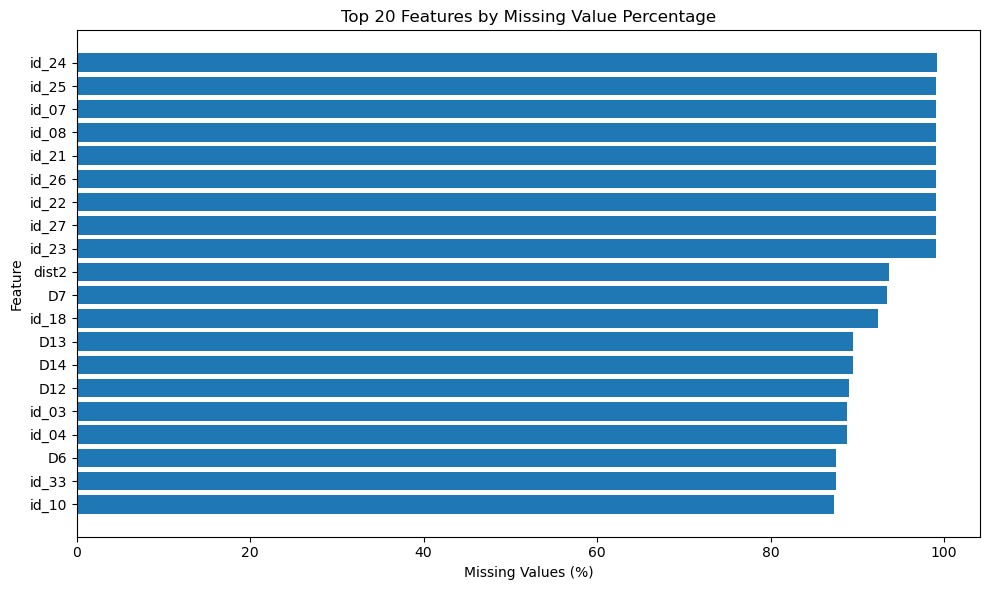

In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
}).sort_values("Missing Percentage", ascending=False)

print("Top 20 features by missing percentage:")
display(missing_summary.head(20))

plt.figure(figsize=(10, 6))

top_20 = missing_summary.head(20).sort_values("Missing Percentage")

plt.barh(
    top_20.index,
    top_20["Missing Percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Top 20 Features by Missing Value Percentage")
plt.tight_layout()
plt.show()

In [5]:
df["has_identity"] = df["DeviceType"].notna().astype(int)

print(
    df.groupby("has_identity")["isFraud"]
      .agg(["count", "mean"])
)

fraud_by_identity = (
    df.groupby("has_identity")["isFraud"]
      .mean()
      .mul(100)
)

print(fraud_by_identity)

               count      mean
has_identity                  
0             449730  0.021017
1             140810  0.079618
has_identity
0    2.101705
1    7.961792
Name: isFraud, dtype: float64


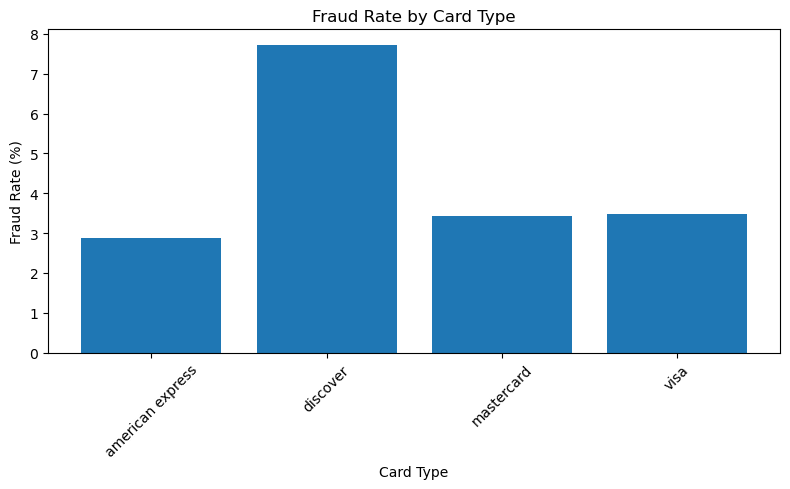

In [6]:
# Calculate fraud rate for each category
fraud_rate = df.groupby("card4")["isFraud"].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(fraud_rate.index.astype(str), fraud_rate.values)

plt.xlabel("Card Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Card Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

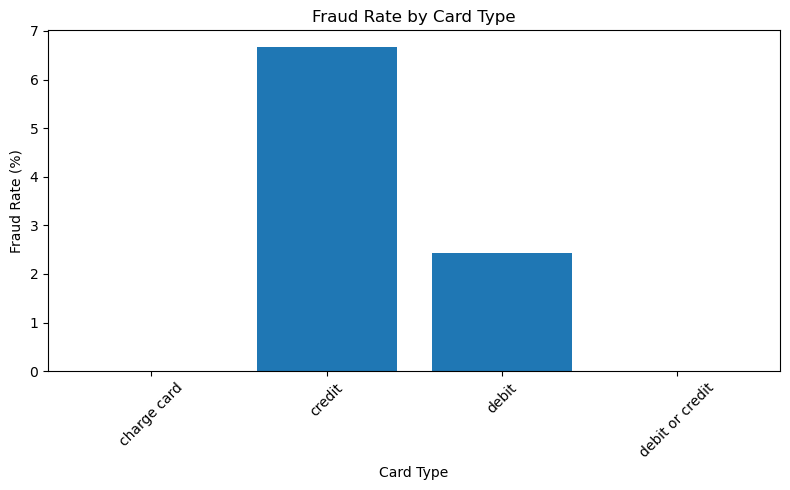

In [7]:
# Calculate fraud rate for each category
fraud_rate = df.groupby("card6")["isFraud"].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(fraud_rate.index.astype(str), fraud_rate.values)

plt.xlabel("Card Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Card Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

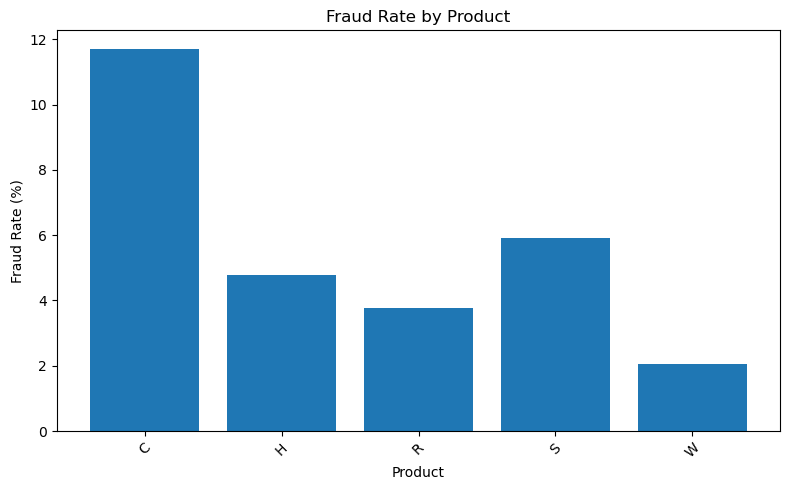

In [8]:
# Calculate fraud rate for each category
fraud_rate = df.groupby("ProductCD")["isFraud"].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(fraud_rate.index.astype(str), fraud_rate.values)

plt.xlabel("Product")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

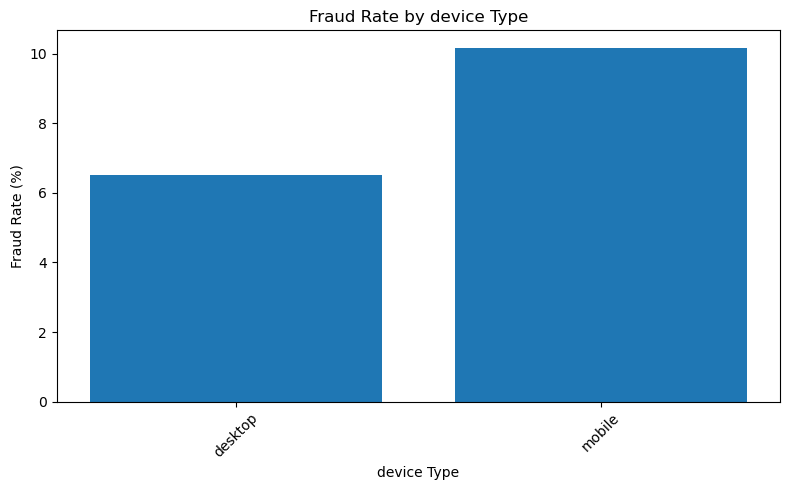

In [9]:
# Calculate fraud rate for each category
fraud_rate = df.groupby("DeviceType")["isFraud"].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(fraud_rate.index.astype(str), fraud_rate.values)

plt.xlabel("device Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by device Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

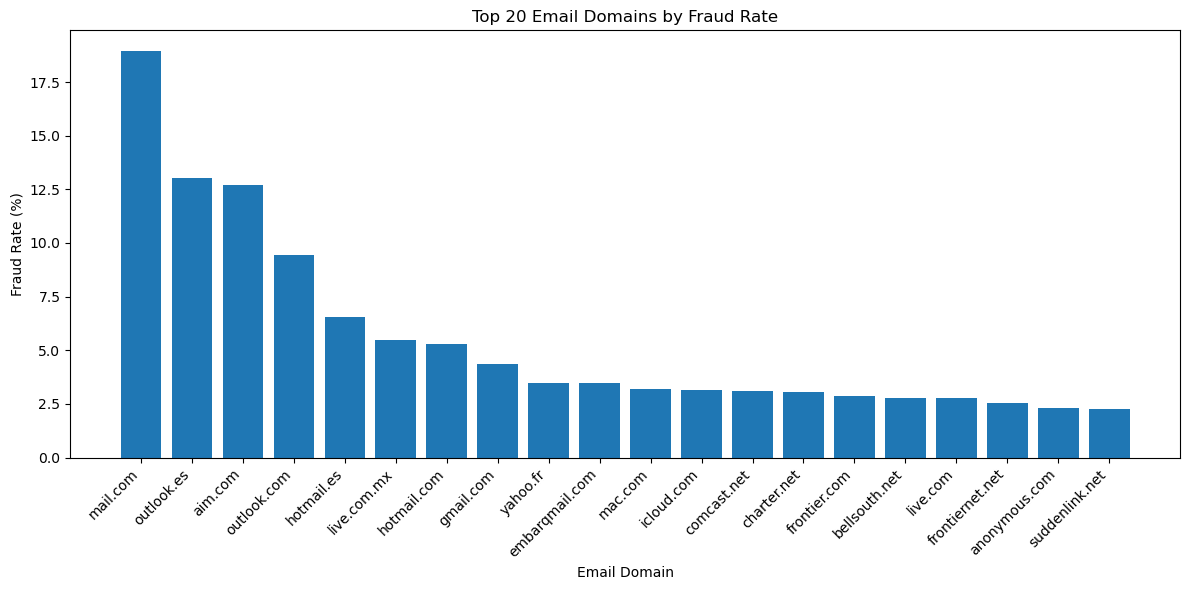

In [49]:
email_stats = (
    df.groupby("P_emaildomain")["isFraud"]
      .agg(["count", "mean"])
)

email_stats = email_stats[email_stats["count"] >= 100]

email_stats["fraud_percentage"] = email_stats["mean"] * 100

top_20_email = (
    email_stats["fraud_percentage"]
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_20_email.index.astype(str),
    top_20_email.values
)

plt.xlabel("Email Domain")
plt.ylabel("Fraud Rate (%)")
plt.title("Top 20 Email Domains by Fraud Rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

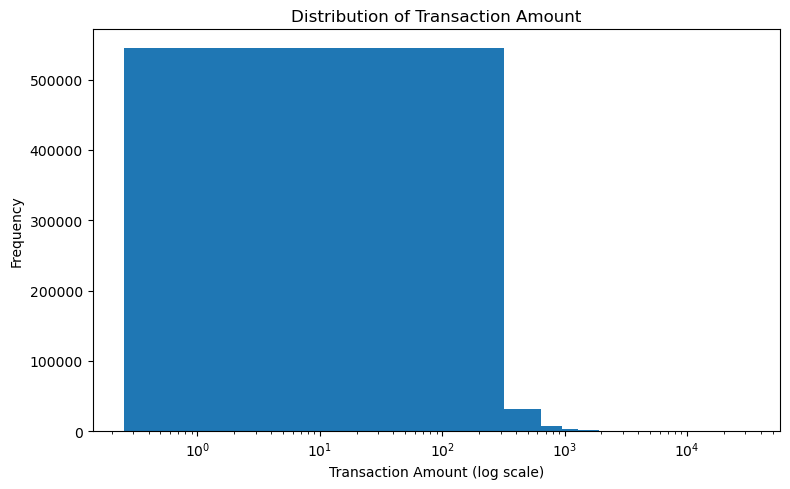

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["TransactionAmt"].dropna(), bins=100)

plt.xscale("log")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")

plt.tight_layout()
plt.show()

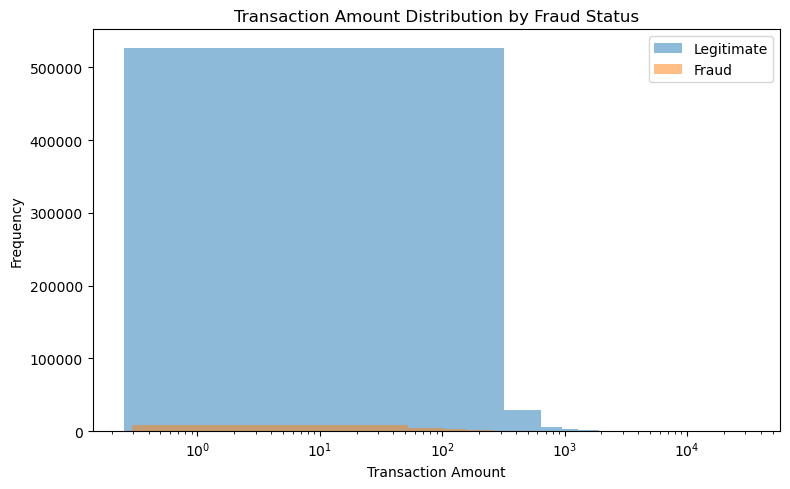

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["isFraud"] == 0, "TransactionAmt"],
    bins=100,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    df.loc[df["isFraud"] == 1, "TransactionAmt"],
    bins=100,
    alpha=0.5,
    label="Fraud"
)
plt.xscale("log")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution by Fraud Status")
plt.legend()

plt.tight_layout()
plt.show()

   TransactionDT  transaction_hour  transaction_day
0          86400                 0                1
1          86401                 0                1
2          86469                 0                1
3          86499                 0                1
4          86506                 0                1
                  count      mean  fraud_percentage
transaction_hour                                   
0                 37795  0.031380          3.137981
1                 32797  0.031314          3.131384
2                 26732  0.037483          3.748317
3                 20802  0.038314          3.831362
4                 14839  0.051890          5.189029
5                  9701  0.070302          7.030203
6                  6007  0.077743          7.774263
7                  3704  0.106102         10.610151
8                  2591  0.093014          9.301428
9                  2479  0.089956          8.995563
10                 3627  0.053212          5.321202
11          

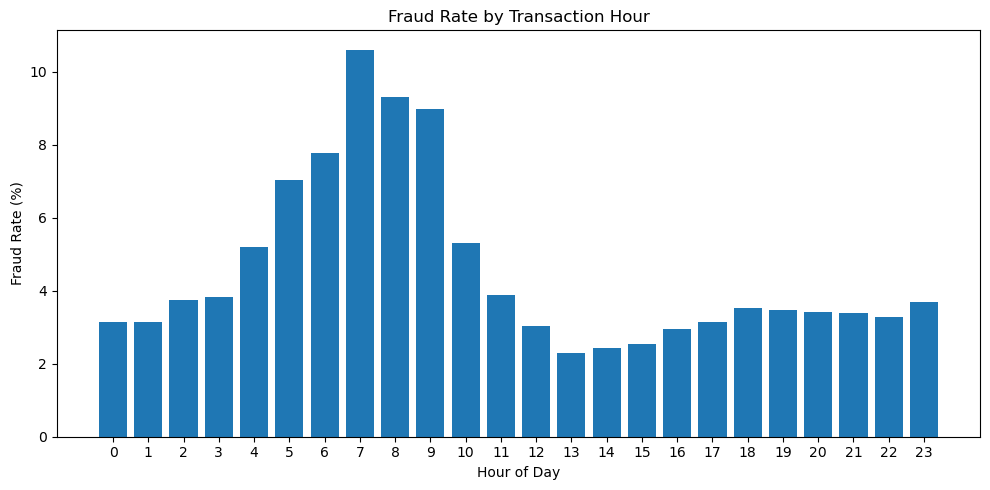

In [13]:
# Convert TransactionDT from seconds into useful time-based features


df["transaction_hour"] = (
    (df["TransactionDT"] // 3600) % 24
).astype(int)

df["transaction_day"] = (
    df["TransactionDT"] // (24 * 3600)
).astype(int)

print(df[["TransactionDT", "transaction_hour", "transaction_day"]].head())

fraud_by_hour = (
    df.groupby("transaction_hour")["isFraud"]
      .agg(["count", "mean"])
)

fraud_by_hour["fraud_percentage"] = fraud_by_hour["mean"] * 100

print(fraud_by_hour)

plt.figure(figsize=(10, 5))

plt.bar(
    fraud_by_hour.index,
    fraud_by_hour["fraud_percentage"]
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [14]:
numeric_df = df.select_dtypes(include=np.number)

correlation_with_fraud = (
    numeric_df.corr()["isFraud"]
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)

print("Top 20 numerical features associated with fraud:")
print(correlation_with_fraud.head(20))

Top 20 numerical features associated with fraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


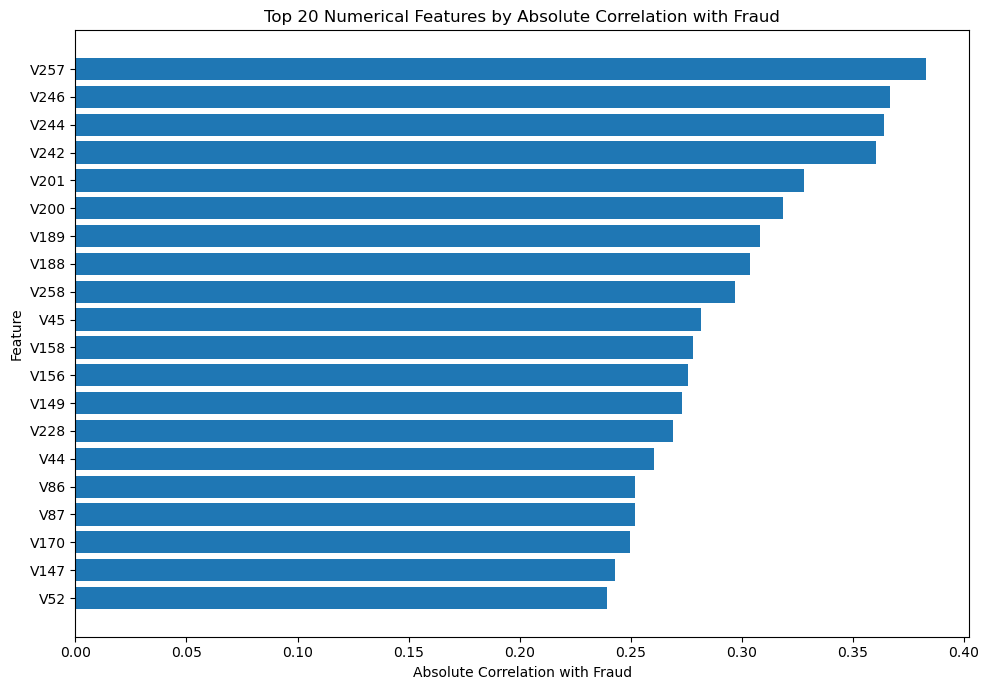

In [15]:
top_20_corr = correlation_with_fraud.head(20).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_corr.index,
    top_20_corr.values
)

plt.xlabel("Absolute Correlation with Fraud")
plt.ylabel("Feature")
plt.title("Top 20 Numerical Features by Absolute Correlation with Fraud")
plt.tight_layout()
plt.show()

In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


amt_bucket
0    121161
1    124763
2    122695
3    104478
4    117443
Name: count, dtype: int64
Fraud rate by transaction amount bucket:
amt_bucket
0    4.375996
1    2.612153
2    3.309018
3    2.696261
4    4.448967
Name: isFraud, dtype: float64


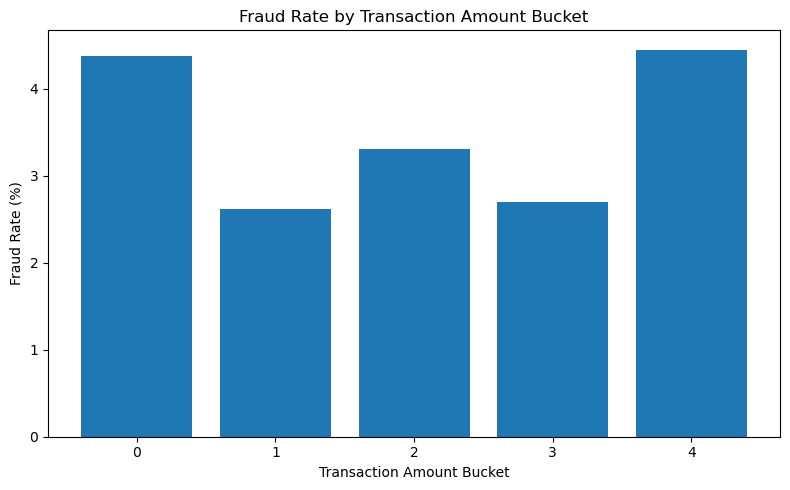

In [17]:
# Divide transaction amounts into five frequency-based buckets
df["amt_bucket"] = pd.qcut(
    df["TransactionAmt"],
    q=5,
    labels=False,
    duplicates="drop"
)

print(df["amt_bucket"].value_counts().sort_index())


fraud_by_amount_bucket = (
    df.groupby("amt_bucket", observed=True)["isFraud"]
      .mean() * 100
)

print("Fraud rate by transaction amount bucket:")
print(fraud_by_amount_bucket)
plt.figure(figsize=(8, 5))

plt.bar(
    fraud_by_amount_bucket.index.astype(str),
    fraud_by_amount_bucket.values
)

plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount Bucket")
plt.tight_layout()
plt.show()


In [18]:
# Sort chronologically
df = df.sort_values("TransactionDT").reset_index(drop=True)

# 70% train, 15% validation, 15% test
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nFraud rates:")
print("Train:", train_df["isFraud"].mean())
print("Validation:", val_df["isFraud"].mean())
print("Test:", test_df["isFraud"].mean())

print("\nFraud counts:")
print("Train:", train_df["isFraud"].sum())
print("Validation:", val_df["isFraud"].sum())
print("Test:", test_df["isFraud"].sum())

Train shape: (413378, 438)
Validation shape: (88581, 438)
Test shape: (88581, 438)

Fraud rates:
Train: 0.03516878014795175
Validation: 0.03434145019812375
Test: 0.03480430340592226

Fraud counts:
Train: 14538
Validation: 3042
Test: 3083


In [19]:
print("Target:", "isFraud")

print("\nTransactionID unique values:",
      df["TransactionID"].nunique(),
      "out of",
      len(df))

print("\nDuplicate TransactionIDs:",
      df["TransactionID"].duplicated().sum())

Target: isFraud



TransactionID unique values: 590540 out of 590540

Duplicate TransactionIDs: 0


In [20]:
# Target
y_train = train_df["isFraud"]
y_val = val_df["isFraud"]
y_test = test_df["isFraud"]

# Remove target and unique identifier
X_train = train_df.drop(columns=["isFraud", "TransactionID"])
X_val = val_df.drop(columns=["isFraud", "TransactionID"])
X_test = test_df.drop(columns=["isFraud", "TransactionID"])

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (413378, 436)
X_val: (88581, 436)
X_test: (88581, 436)

y_train: (413378,)
y_val: (88581,)
y_test: (88581,)


In [21]:
# Check feature data types
print(X_train.dtypes.value_counts())

# Count categorical and numerical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("\nCategorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

print("\nFirst 20 categorical features:")
print(categorical_cols[:20])
all_categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
print(all_categorical_cols)

float64    399
object      31
int64        6
Name: count, dtype: int64



Categorical features: 31
Numerical features: 405

First 20 categorical features:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28']


['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [22]:
# Create CatBoost-ready copies
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

# Convert categorical columns to strings and explicitly
# represent missing categorical values as "Missing"
for col in categorical_cols:
    X_train_cb[col] = (
        X_train_cb[col]
        .astype("object")
        .fillna("Missing")
        .astype(str)
    )

    X_val_cb[col] = (
        X_val_cb[col]
        .astype("object")
        .fillna("Missing")
        .astype(str)
    )

    X_test_cb[col] = (
        X_test_cb[col]
        .astype("object")
        .fillna("Missing")
        .astype(str)
    )

print("Categorical preprocessing complete.")

print("\nRemaining categorical missing values:")
print(X_train_cb[categorical_cols].isna().sum().sum())

Categorical preprocessing complete.

Remaining categorical missing values:


0


In [23]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

fraud_weight = negative / positive

print("Legitimate transactions:", negative)
print("Fraudulent transactions:", positive)
print("Fraud class weight:", fraud_weight)

Legitimate transactions: 398840
Fraudulent transactions: 14538
Fraud class weight: 27.434310083918007


In [24]:
print(X_val_cb.head())

        TransactionDT  TransactionAmt ProductCD  card1  card2  card3  \
413378       10438003            49.0         W   7239  452.0  150.0   
413379       10438017          1265.5         W  18227  583.0  150.0   
413380       10438043            50.0         H  11919  170.0  150.0   
413381       10438052           161.0         W   2377  203.0  150.0   
413382       10438065            88.0         W   7919  194.0  150.0   

             card4  card5   card6  addr1  ...    id_35    id_36    id_37  \
413378  mastercard  117.0   debit  264.0  ...  Missing  Missing  Missing   
413379        visa  226.0  credit  472.0  ...  Missing  Missing  Missing   
413380  mastercard  224.0   debit  126.0  ...        T        F        F   
413381        visa  166.0   debit  123.0  ...  Missing  Missing  Missing   
413382  mastercard  166.0   debit  315.0  ...  Missing  Missing  Missing   

          id_38 DeviceType  DeviceInfo  has_identity  transaction_hour  \
413378  Missing    Missing     Missi

In [24]:
from catboost import CatBoostClassifier

baseline_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=categorical_cols,
    class_weights=[1, fraud_weight],
    random_seed=42,
    verbose=50,
    early_stopping_rounds=50,
    thread_count=-1
)

baseline_model.fit(
    X_train_cb,
    y_train,
    eval_set=(X_val_cb, y_val)
)
baseline_model.save_model("baseline_model.cbm")

print("Model saved successfully.")

0:	test: 0.8149511	best: 0.8149511 (0)	total: 5.15s	remaining: 25m 40s


50:	test: 0.8629999	best: 0.8629999 (50)	total: 3m 52s	remaining: 18m 55s


100:	test: 0.8731784	best: 0.8731784 (100)	total: 7m 48s	remaining: 15m 23s


150:	test: 0.8794944	best: 0.8795005 (149)	total: 11m 22s	remaining: 11m 13s


200:	test: 0.8837452	best: 0.8838031 (198)	total: 14m 50s	remaining: 7m 18s


250:	test: 0.8881376	best: 0.8881376 (250)	total: 18m 36s	remaining: 3m 37s


299:	test: 0.8931229	best: 0.8931229 (299)	total: 22m 18s	remaining: 0us

bestTest = 0.8931228866
bestIteration = 299



Model saved successfully.


In [25]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
baseline_model = CatBoostClassifier()
baseline_model.load_model("baseline_model.cbm")

print("Model loaded successfully.")

# Predict probabilities
val_proba = baseline_model.predict_proba(X_val_cb)[:, 1]

# Standard threshold
val_pred = (val_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, val_proba))
print("PR-AUC:", average_precision_score(y_val, val_proba))

print("\nClassification Report:")
print(classification_report(y_val, val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

Model loaded successfully.


ROC-AUC: 0.8752981893775972
PR-AUC: 0.4665694692634407

Classification Report:


              precision    recall  f1-score   support

           0       0.99      0.93      0.95     85539
           1       0.23      0.64      0.34      3042

    accuracy                           0.92     88581
   macro avg       0.61      0.78      0.65     88581
weighted avg       0.96      0.92      0.93     88581


Confusion Matrix:
[[79126  6413]
 [ 1086  1956]]


In [26]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_proba
)

# F1 score at each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", best_f1)

Best threshold: 0.7326977724825523
Precision: 0.546284224250326
Recall: 0.41321499013806706
F1: 0.4705221785023373


In [ ]:
improved_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=categorical_cols,
    class_weights=[1, fraud_weight],
    random_seed=42,
    verbose=100,
    early_stopping_rounds=75,
    thread_count=-1
)

improved_model.fit(
    X_train_cb,
    y_train,
    eval_set=(X_val_cb, y_val)
)
improved_model.save_model("improved_model.cbm")

print("Model saved successfully.")

In [28]:
improved_model = CatBoostClassifier()
improved_model.load_model("improved_model.cbm")

CatBoostClassifier(class_weights=[1, 27.43431008], depth=6, eval_metric='AUC', iterations=600, learning_rate=0.05, loss_function='Logloss', od_wait=75, random_seed=42, verbose=100)

In [38]:
improved_val_proba = improved_model.predict_proba(X_val_cb)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [39]:
# Find the threshold that maximizes F1 on the validation set

precision, recall, thresholds = precision_recall_curve(
    y_val,
    improved_val_proba
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = f1_scores.argmax()

improved_best_threshold = thresholds[best_idx]
improved_best_precision = precision[best_idx]
improved_best_recall = recall[best_idx]
improved_best_f1 = f1_scores[best_idx]

print("Best threshold:", improved_best_threshold)
print("Precision:", improved_best_precision)
print("Recall:", improved_best_recall)
print("F1:", improved_best_f1)

Best threshold: 0.7109766117814699
Precision: 0.5580319596299411
Recall: 0.4362261669953978
F1: 0.4896678966297172


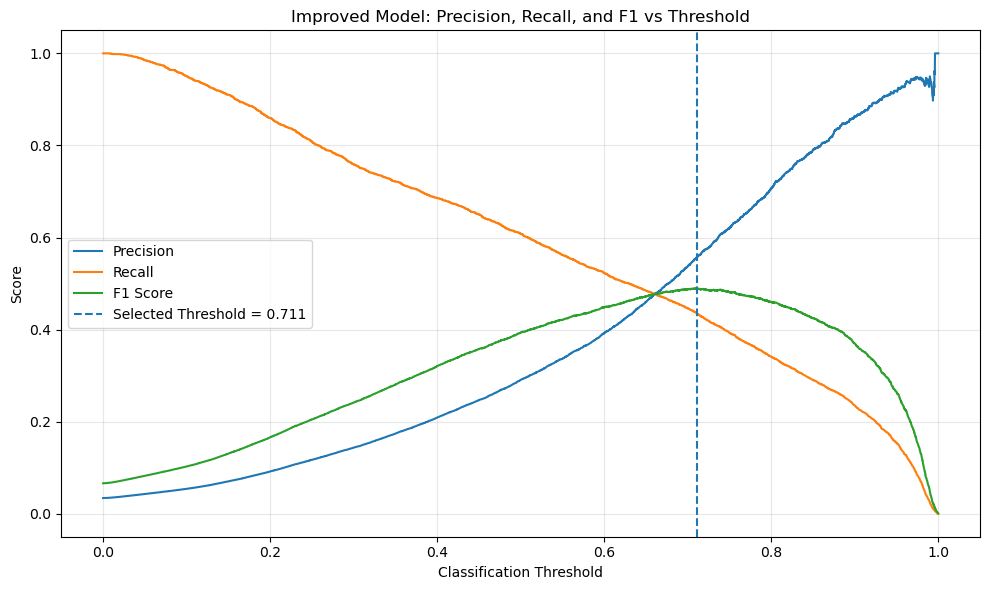

In [40]:
# Plot threshold trade-offs for the improved model

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.axvline(
    improved_best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {improved_best_threshold:.3f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Improved Model: Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Apply the validation-selected threshold to the unseen test set

y_test_final = (
    y_pred_proba >= improved_best_threshold
).astype(int)

print("Final threshold:", improved_best_threshold)

Final threshold: 0.7109766117814699


In [42]:
# Final evaluation of the improved model

cm_final = confusion_matrix(y_test, y_test_final)

print("Final Confusion Matrix:")
print(cm_final)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        y_test_final,
        digits=4
    )
)

roc_auc_final = roc_auc_score(y_test, y_pred_proba)
pr_auc_final = average_precision_score(y_test, y_pred_proba)

print(f"Final ROC-AUC: {roc_auc_final:.4f}")
print(f"Final PR-AUC: {pr_auc_final:.4f}")

Final Confusion Matrix:
[[84216  1282]
 [ 1753  1330]]

Final Classification Report:
              precision    recall  f1-score   support

           0     0.9796    0.9850    0.9823     85498
           1     0.5092    0.4314    0.4671      3083

    accuracy                         0.9657     88581
   macro avg     0.7444    0.7082    0.7247     88581
weighted avg     0.9632    0.9657    0.9644     88581

Final ROC-AUC: 0.8707
Final PR-AUC: 0.4476


In [44]:
# Select a representative sample for SHAP analysis
shap_sample = X_test_cb.sample(
    n=min(1000, len(X_test_cb)),
    random_state=42
)

print("SHAP sample shape:", shap_sample.shape)

SHAP sample shape: (1000, 436)


In [45]:
# Create SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(improved_model)

shap_values = explainer.shap_values(shap_sample)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (1000, 436)


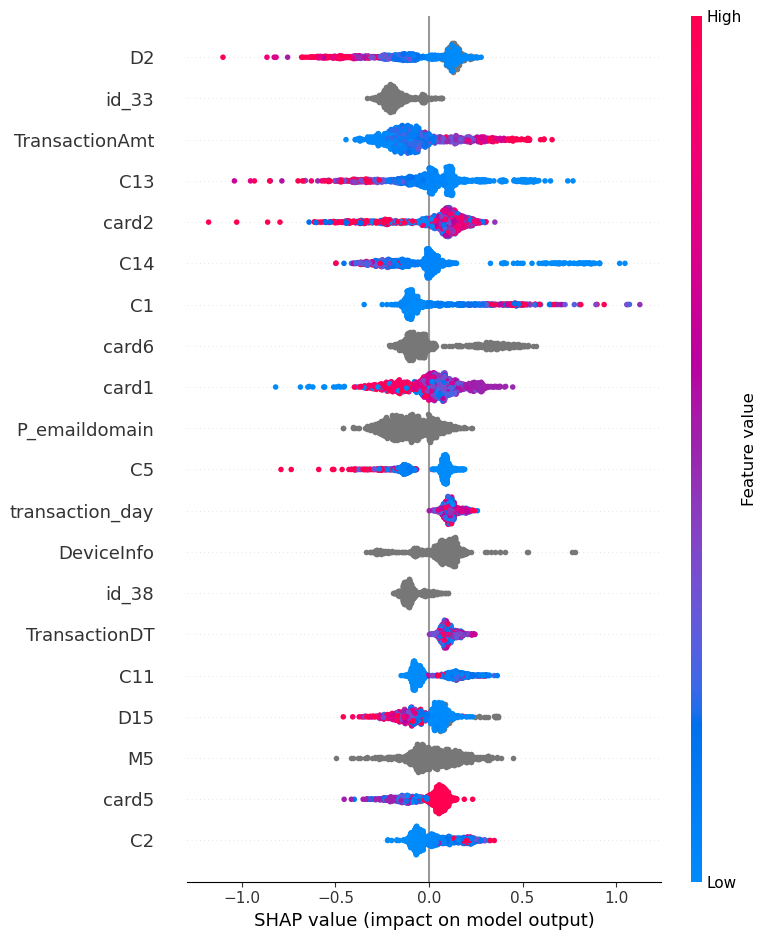

In [46]:
# Global feature importance and direction of influence
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20
)

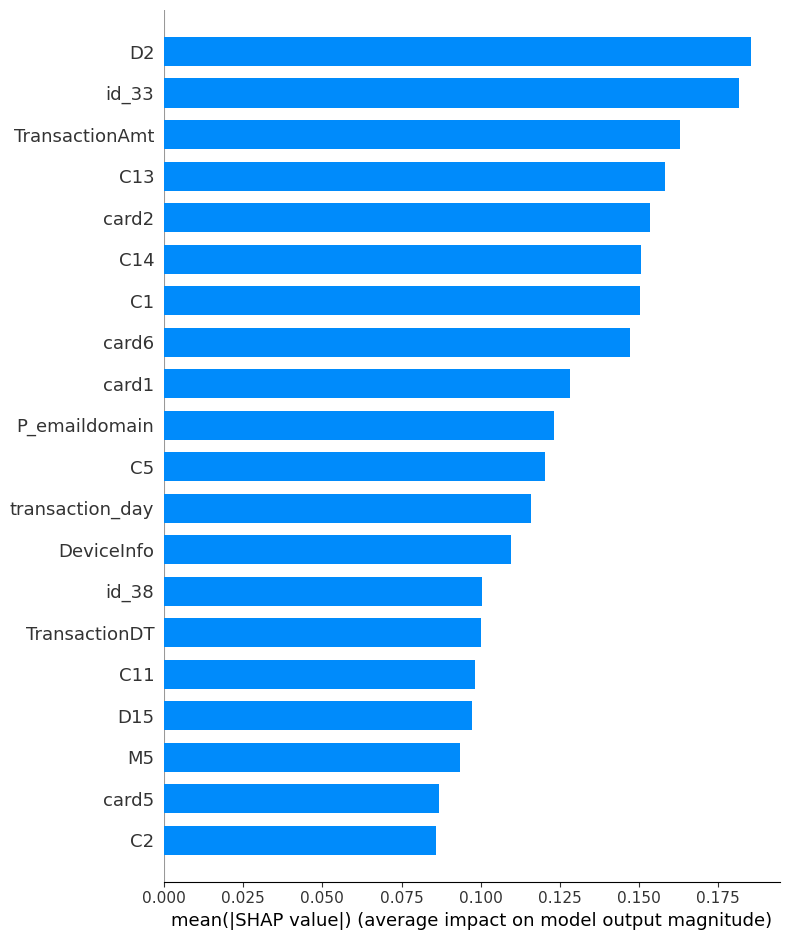

In [47]:
# Global feature importance based on mean absolute SHAP values
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    max_display=20
)